Design and implement a Convolutional Neural Network (CNN) for image classification using the Tomato or Soybean disease dataset.

In [1]:
!pip install -q kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
import kagglehub

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
print("GPU available:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("Using GPU")
else:
    print("Using CPU")

GPU available: []
Using CPU


In [3]:
path = kagglehub.dataset_download(
    "yusufmurtaza01/tomato-leaf-dataset-for-disease-detection"
)

print("Dataset downloaded at:")
print(path)

100%|██████████| 280M/280M [00:14<00:00, 20.5MB/s]

Extracting files...


Dataset downloaded at:
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2


In [4]:
dataset_path = os.path.join(
    path,
    "tomato_yolo_dataset"
)

if os.path.exists(dataset_path):
    DATA_DIR = dataset_path
else:
    DATA_DIR = path

print("Dataset directory:")
print(DATA_DIR)

print("\nContents:")
print(os.listdir(DATA_DIR))

Dataset directory:
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset

Contents:
['labels', 'images']


In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 6
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Image size: (128, 128)
Batch size: 32
Epochs: 10


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Training dataset loaded.")

Found 18158 files belonging to 2 classes.
Using 14527 files for training.
Training dataset loaded.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Validation dataset loaded.")

Found 18158 files belonging to 2 classes.
Using 3631 files for validation.
Validation dataset loaded.


In [8]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:")

for i, name in enumerate(class_names):
    print(i, ":", name)

print("\nNumber of classes:", num_classes)

Class names:
0 : images
1 : labels

Number of classes: 2


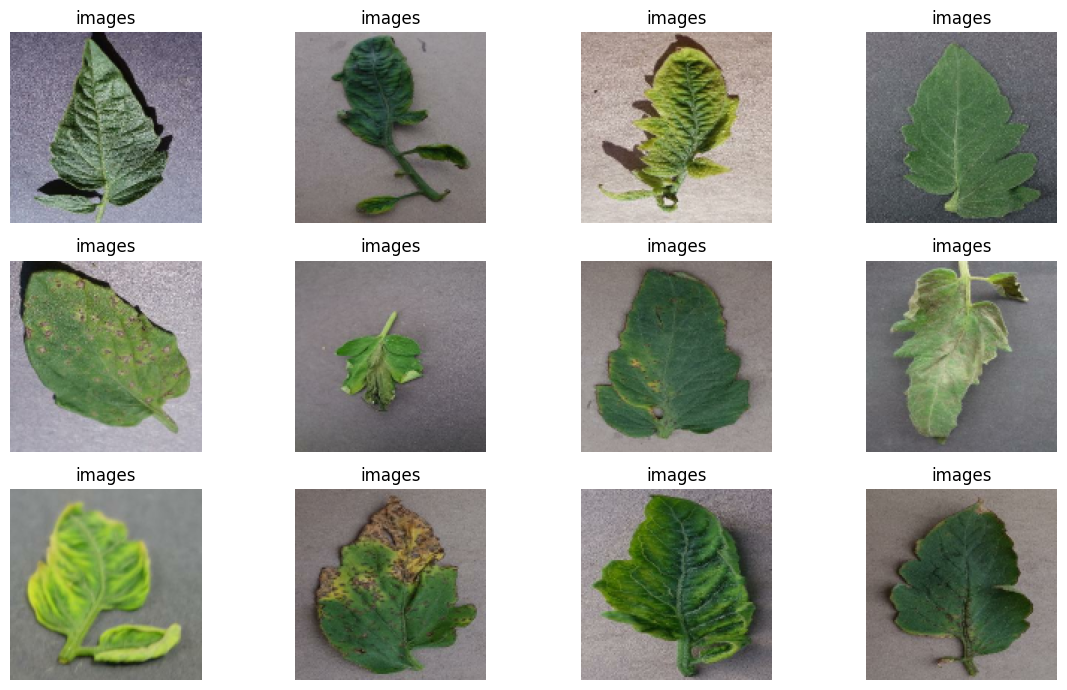

In [9]:
plt.figure(figsize=(12, 7))

for images, labels in train_ds.take(1):

    for i in range(min(12, len(images))):

        plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
])

print("Data augmentation created.")

Data augmentation created.


In [12]:
model = models.Sequential([

    layers.Input(
        shape=(128, 128, 3)
    ),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values
    layers.Rescaling(
        1.0 / 255
    ),

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Additional convolution block
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Classification layers
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(
        0.4
    ),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,570 (1.61 MB)

 Trainable params: 421,570 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 764s 2s/step - accuracy: 0.9981 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 758s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 746s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 748s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 739s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 709s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 736s 

In [21]:
val_loss, val_accuracy = model.evaluate(
    val_ds
)

print(
    f"Validation Loss: {val_loss:.4f}"
)

print(
    f"Validation Accuracy: {val_accuracy * 100:.2f}%"
)

114/114 ━━━━━━━━━━━━━━━━━━━━ 45s 394ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Validation Loss: 0.0000
Validation Accuracy: 100.00%


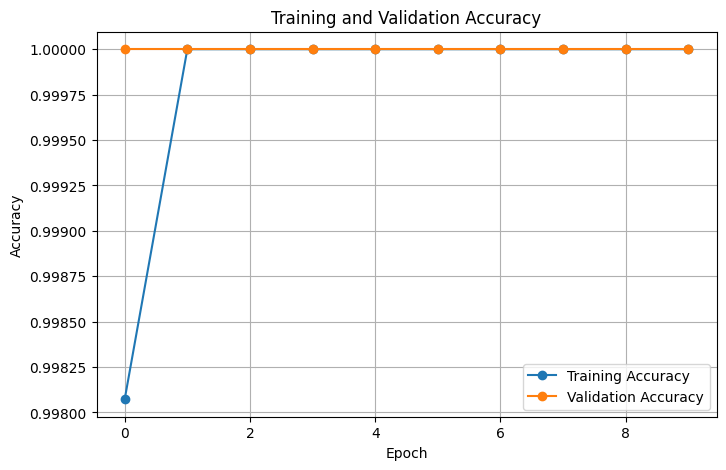

In [16]:
train_accuracy = history.history[
    "accuracy"
]

val_accuracy_history = history.history[
    "val_accuracy"
]

plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    val_accuracy_history,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()

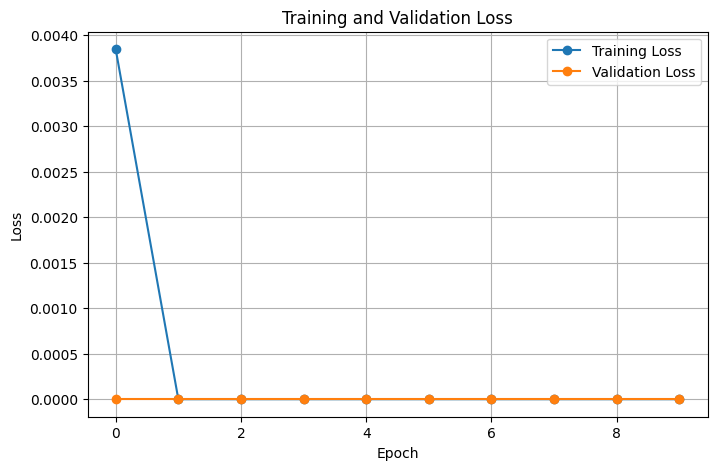

In [17]:
train_loss = history.history[
    "loss"
]

val_loss_history = history.history[
    "val_loss"
]

plt.figure(figsize=(8, 5))

plt.plot(
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_loss_history,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

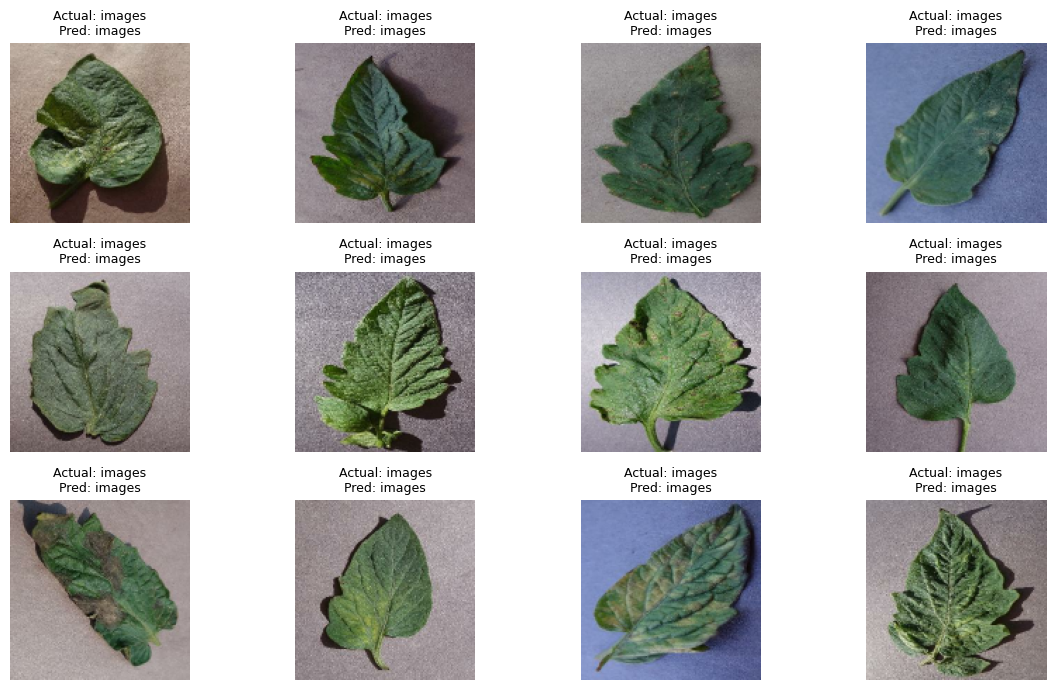

In [18]:
plt.figure(figsize=(12, 7))

for images, labels in val_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(min(12, len(images))):

        plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual = class_names[
            labels[i]
        ]

        predicted = class_names[
            predicted_classes[i]
        ]

        plt.title(
            f"Actual: {actual}\nPred: {predicted}",
            fontsize=9
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
model.save(
    "tomato_leaf_disease_cnn.keras"
)

print(
    "Model saved successfully."
)

Model saved successfully.


In [20]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(
    f"Number of classes: {num_classes}"
)

print(
    f"Image size: {IMG_SIZE}"
)

print(
    f"Epochs: {EPOCHS}"
)

print(
    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)

print(
    f"Validation Loss: "
    f"{val_loss:.4f}"
)

FINAL MODEL RESULTS
Number of classes: 2
Image size: (128, 128)
Epochs: 10
Validation Accuracy: 100.00%
Validation Loss: 0.0000
